In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt


# 1. set up and load data

In [2]:

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata = sc.read_h5ad(filename)
adata = adata[adata.obs['leiden']!='5',:]

sc.pp.normalize_total(adata, 1e4)

sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_scVI')
sc.tl.umap(adata)


/scratch/fast/1257775/ipykernel_1343701/2745660570.py:5: FutureWarning: The specified parameters ('target_sum',) are no longer positional. Please specify them like `target_sum=10000.0`
  sc.pp.normalize_total(adata, 1e4)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


In [4]:
adata.shape

(2252, 315)

# 2. Explore Leiden across multiple resolutions


In [5]:
adata.obsm['X_umap']

array([[3.14981   , 5.4495897 ],
       [3.3060665 , 1.7255371 ],
       [2.7982717 , 4.4900293 ],
       ...,
       [5.322023  , 3.0108714 ],
       [0.92105174, 2.2726476 ],
       [5.9140906 , 1.4803823 ]], dtype=float32)

In [7]:
# 2.1 Define the grid of resolutions to test
resolutions = [0.15, 0.2, 0.3, 0.4,0.5, 0.6, .7, 0.8, .9, 1.0]

results = []

for res in resolutions:
    key = f'leiden_{res}'
    
    sc.tl.leiden(adata, resolution=res, key_added=key)
    labels = adata.obs[key].astype('category').cat.codes.values
    n_clusters = len(np.unique(labels))
    sil = silhouette_score(adata.obsm['X_umap'], labels)
    
    # 2.3 Stability: mean ARI over 5 random 80% subsamples
    aris = []
    for _ in range(5):
        idx = np.random.choice(adata.n_obs, size=int(adata.n_obs*0.8), replace=False)
        sub = adata[idx]
        sc.tl.leiden(sub, resolution=res, key_added='leiden_sub')
        lab_sub = sub.obs['leiden_sub'].astype('category').cat.codes.values
        # compare to full‐data labels restricted to the same cells
        full_lab = labels[idx]
        aris.append(adjusted_rand_score(full_lab, lab_sub))
    ari_mean = np.mean(aris)
    
    results.append({
        'resolution': res,
        'n_clusters': n_clusters,
        'silhouette': sil,
        'ARI_stability': ari_mean
    })

metrics = pd.DataFrame(results)
display(metrics)


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

,resolution,n_clusters,silhouette,ARI_stability
0,0.15,2,0.378269,0.745463
1,0.20,2,0.377549,0.390456
2,0.30,4,0.356906,0.600731
3,0.40,4,0.403821,0.752380
4,0.50,4,0.408449,0.738796
5,0.60,7,0.270867,0.543151
6,0.70,8,0.233159,0.535843
7,0.80,10,0.236355,0.578974
8,0.90,10,0.217299,0.539504
9,1.00,9,0.223441,0.478113


# 3. Visualize metrics
## 3.1 Resolution vs. Silhouette Score

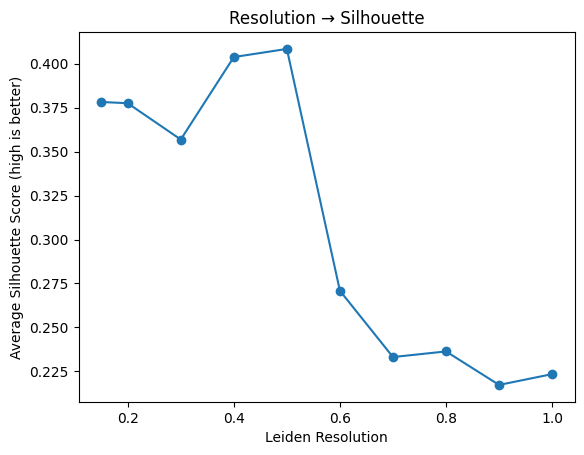

In [8]:
plt.figure()
plt.plot(metrics['resolution'], metrics['silhouette'], marker='o')
plt.xlabel('Leiden Resolution')
plt.ylabel('Average Silhouette Score (high is better)')
plt.title('Resolution → Silhouette')
plt.show()


## 3.2 Resolution vs. Number of Clusters

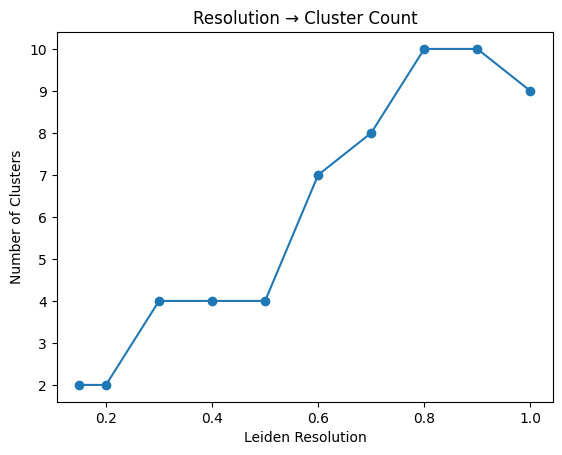

In [9]:
plt.figure()
plt.plot(metrics['resolution'], metrics['n_clusters'], marker='o')
plt.xlabel('Leiden Resolution')
plt.ylabel('Number of Clusters')
plt.title('Resolution → Cluster Count')
plt.show()


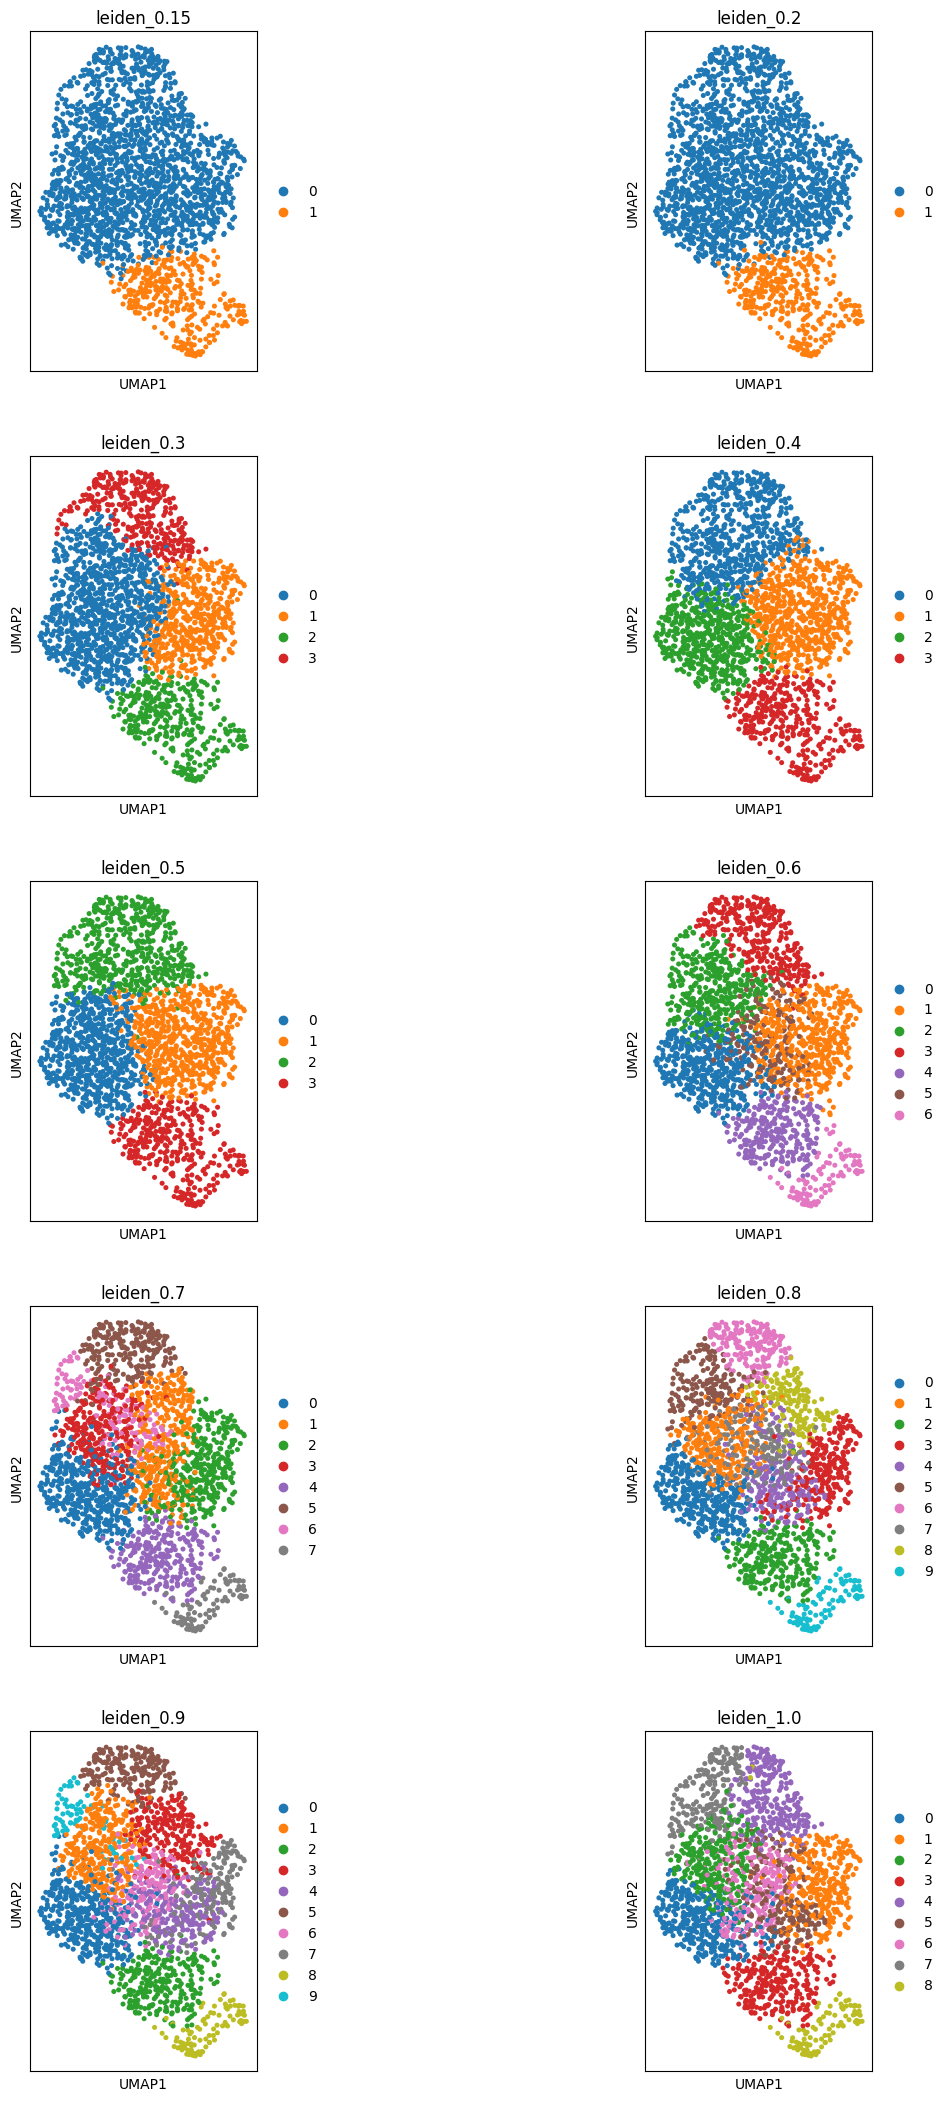

In [10]:
axes = sc.pl.umap(adata, color=[f'leiden_{res}' for res in resolutions], show = False, ncols = 2)
for a in axes: a.set_aspect('equal')

# 3.3 Resolution vs. ARI (Stability, Adjusted Rand Index.)

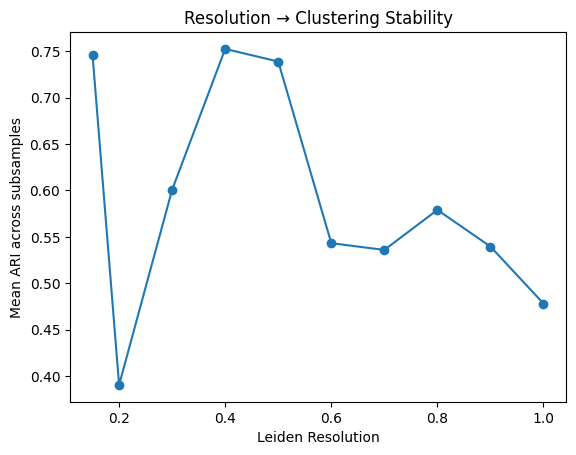

In [11]:
plt.figure()
plt.plot(metrics['resolution'], metrics['ARI_stability'], marker='o')
plt.xlabel('Leiden Resolution')
plt.ylabel('Mean ARI across subsamples')
plt.title('Resolution → Clustering Stability')
plt.show()


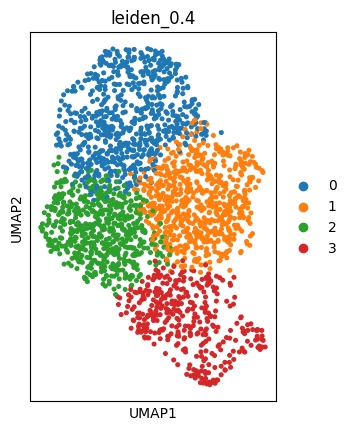

In [12]:
a = sc.pl.umap(adata, color='leiden_0.4', show = False)
a.set_aspect('equal')

# 4. permutation for the significant testing
permutation test:   

1. computing the actual silhouette score for Leiden clusters at resolution 0.4 (or any given resolution)
2. generating a null distribution by shuffling cluster labels `n_perm` times
3. estimating a p-value for how often random labelings achieve an equal or higher silhouette.

Actual silhouette score (resolution 0.4): 0.404
P-value from permutation test: 0.000


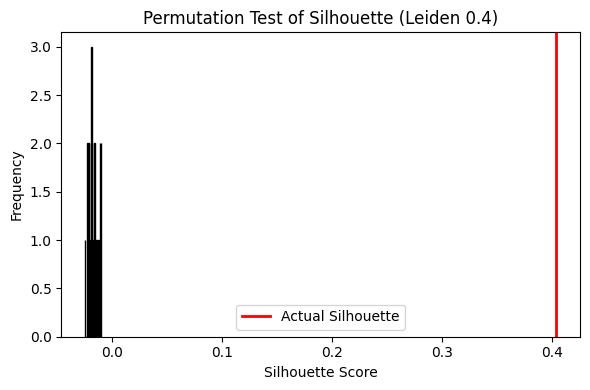

In [13]:
res = .4

# Compute Leiden clustering at the given resolution
sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
labels = adata.obs[f'leiden_{res}'].astype('category').cat.codes.values
umap_coords = adata.obsm['X_umap']

# Calculate actual silhouette score
actual_sil = silhouette_score(umap_coords, labels)
print(f"Actual silhouette score (resolution {res}): {actual_sil:.3f}")

# Permutation test
n_perm = 30
perm_sils = np.zeros(n_perm)
for i in range(n_perm):
    perm_labels = np.random.permutation(labels)
    perm_sils[i] = silhouette_score(umap_coords, perm_labels)

# Calculate p-value
p_value = np.mean(perm_sils >= actual_sil)
print(f"P-value from permutation test: {p_value:.3f}")

# Plot histogram of permuted silhouette scores
plt.figure(figsize=(6,4))
plt.hist(perm_sils, bins=30, edgecolor='black')
plt.axvline(actual_sil, color='red', linewidth=2, label='Actual Silhouette')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.title(f'Permutation Test of Silhouette (Leiden {res})')
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
umap_coords.shape

(2252, 2)

In [15]:
perm_sils.shape

(30,)

# 5. consensus
1. take random 80 % subsamples of cells and re-cluster
2. check if we get (almost) the same assignments
3. build a consensus matrix with co-occurrence frequencies

In [16]:

from scipy.sparse import csr_matrix

n_cells = adata.n_obs
consensus = np.zeros((n_cells, n_cells))
n_runs = 10

for run in range(n_runs):
    idx = np.random.choice(n_cells, size=int(0.8*n_cells), replace=False)
    sub = adata[idx]
    sc.tl.leiden(sub, resolution=res, key_added='tmp')
    lab_sub = sub.obs['tmp'].astype('category').cat.codes.values
    # for every pair that lands in the same sub-cluster, increment
    for i, ci in enumerate(idx):
        same = idx[lab_sub == lab_sub[i]]
        consensus[ci, same] += 1

# normalize
consensus /= n_runs

# now `consensus[i,j]` is the fraction of times i & j co-clustered
# you can visualize it as a heatmap to see if the blocks are tight.




/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

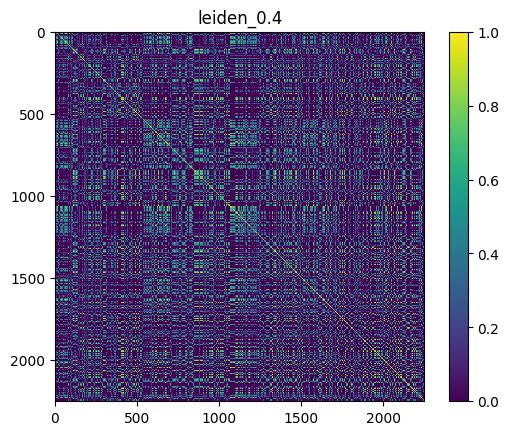

In [17]:
plt.imshow(consensus, interpolation = 'nearest')
plt.title(f'leiden_{res}')
plt.colorbar()

In [18]:
(consensus.T== consensus).all()

np.True_

### get the mean consensus score 

In [19]:
labels = adata.obs[f'leiden_{res}'].astype('category').cat.codes.values
n = adata.n_obs
# consensus is an (n,n) numpy array
cluster_scores = {}
for cl in np.unique(labels):
    idx = np.where(labels == cl)[0]
    if len(idx) > 1:
        # extract the submatrix, exclude diagonal
        sub = consensus[np.ix_(idx, idx)]
        # sum of off-diagonals
        s = sub.sum() - sub.trace()
        count = len(idx)*(len(idx)-1)
        cluster_scores[cl] = s / count
    else:
        cluster_scores[cl] = np.nan  # singleton
print("Mean within-cluster consensus:", cluster_scores)
print('average:',np.sum(list(cluster_scores.values()))/len(cluster_scores))

Mean within-cluster consensus: {np.int8(0): np.float64(0.39172724392729014), np.int8(1): np.float64(0.5200915440814783), np.int8(2): np.float64(0.5558876779226967), np.int8(3): np.float64(0.5643191855677819)}
average: 0.5080064128748117


# consensus across different leiden resolutions
1. link:[Consensus Clustering: A Resampling-Based Method for Class Discovery and Visualization of Gene Expression Microarray Data](https://link.springer.com/article/10.1023/A:1023949509487)
2. [ConsensusClusterPlus](https://academic.oup.com/bioinformatics/article/26/12/1572/281699)



In [20]:
n_cells = adata.n_obs
consensus = np.zeros((n_cells, n_cells))
n_runs = 10

consensus_scores = dict()
for res in resolutions:
    for run in range(n_runs):
        idx = np.random.choice(n_cells, size=int(0.8*n_cells), replace=False)
        sub = adata[idx]
        sc.tl.leiden(sub, resolution=res, key_added='tmp')
        lab_sub = sub.obs['tmp'].astype('category').cat.codes.values
        # for every pair that lands in the same sub-cluster, increment
        for i, ci in enumerate(idx):
            same = idx[lab_sub == lab_sub[i]]
            consensus[ci, same] += 1
    consensus /= n_runs
    
    labels = adata.obs[f'leiden_{res}'].astype('category').cat.codes.values
    n = adata.n_obs
    # consensus is an (n,n) numpy array
    cluster_scores = {}
    for cl in np.unique(labels):
        idx = np.where(labels == cl)[0]
        if len(idx) > 1:
            # extract the submatrix, exclude diagonal
            sub = consensus[np.ix_(idx, idx)]
            # sum of off-diagonals
            s = sub.sum() - sub.trace()
            count = len(idx)*(len(idx)-1)
            cluster_scores[cl] = s / count
        else:
            cluster_scores[cl] = np.nan  # singleton
#     print("Mean within-cluster consensus:", cluster_scores)
#     print(res, 'average:',np.sum(list(cluster_scores.values()))/len(cluster_scores))
    consensus_scores[res] = np.sum(list(cluster_scores.values()))/len(cluster_scores)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view 

Text(0.5, 1.0, 'Resolution → consensus scores')

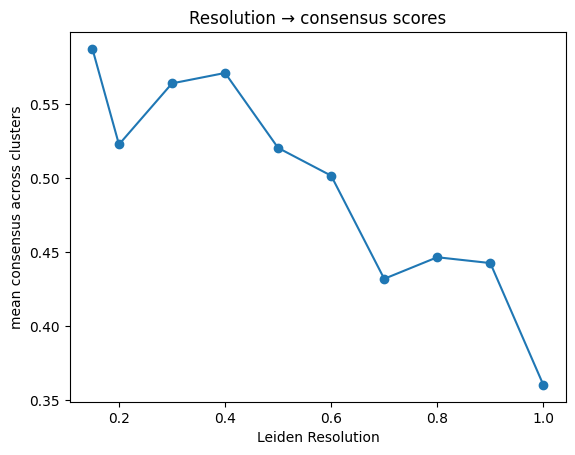

In [21]:
plt.plot(consensus_scores.keys(), consensus_scores.values(), '-o')
plt.xlabel('Leiden Resolution')
plt.ylabel('mean consensus across clusters')
plt.title('Resolution → consensus scores')


# 5. graph modularity

In [22]:
import igraph as ig

# build igraph from Scanpy’s connectivity
conn = adata.obsp['connectivities']
sources, targets = conn.nonzero()
g = ig.Graph(edges=list(zip(sources.tolist(), targets.tolist())), directed=False)

labels = adata.obs[f'leiden_{res}'].astype('category').cat.codes.tolist()
mod_score = g.modularity(labels)
print(f"Graph modularity at res={res}: {mod_score:.3f}")

Graph modularity at res=1.0: 0.596


# 6. DE genes

In [23]:
sc.tl.rank_genes_groups(adata, f'leiden_{res}', method='t-test')
# sc.pl.rank_genes_groups_heatmap(adata, n_genes=5)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 315 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


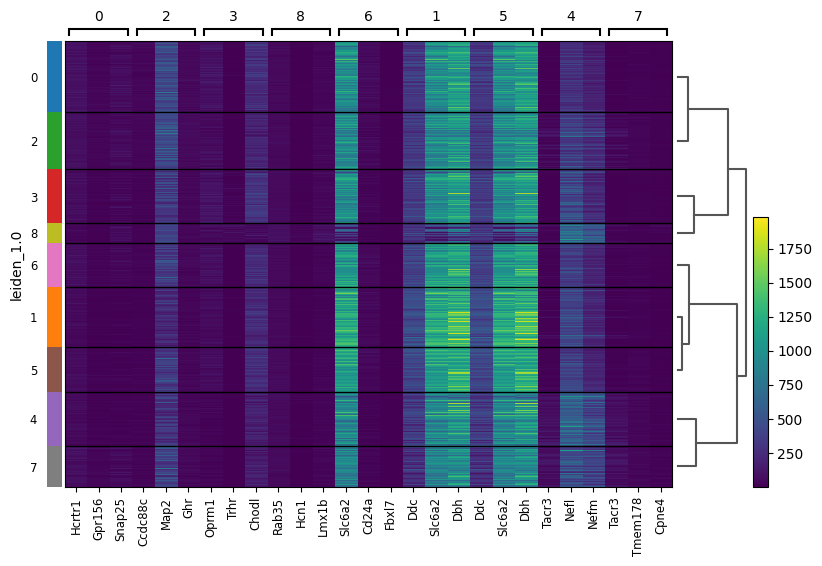

In [24]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=3)

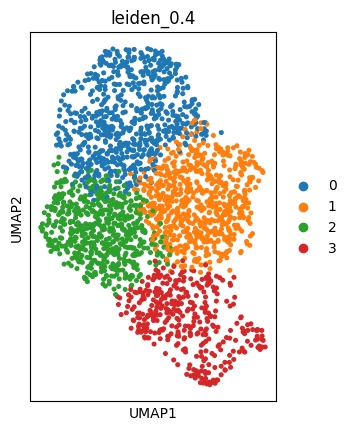

In [25]:
a = sc.pl.umap(adata, color=f'leiden_0.4', show = False)
a.set_aspect('equal')

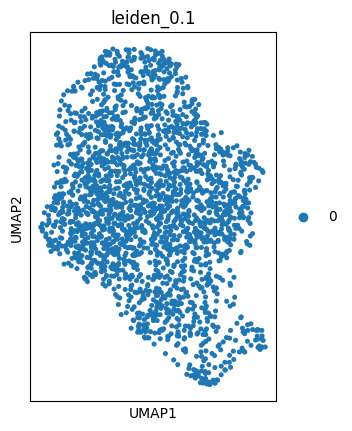

In [26]:
a = sc.pl.umap(adata, color=f'leiden_0.1', show = False)
a.set_aspect('equal')